In [2]:
import rasterio
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
b2 = rasterio.open('B2.tif')
b3 = rasterio.open('B3.tif')
b4 = rasterio.open('B4.tif')
b8 = rasterio.open('B8.tif')
b11 = rasterio.open('B11.tif')
print("B2:", b2.shape, b2.res)
print('B3:', b3.shape, b3.res)
print('B4:', b4.shape, b4.res)
print('B8:', b8.shape, b8.res)
print('B11:', b11.shape, b11.res)


B2: (2019, 1426) (10.0, 10.0)
B3: (2019, 1426) (10.0, 10.0)
B4: (2019, 1426) (10.0, 10.0)
B8: (2019, 1426) (10.0, 10.0)
B11: (1010, 714) (20.0, 20.0)


In [5]:
print("B8 CRS:", b8.crs)
print("B11 CRS:", b11.crs)

print("B8 NoData:", b8.nodata)
print("B11 NoData:", b11.nodata)

B8 CRS: PROJCS["WGS_1984_UTM_Zone_44N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
B11 CRS: PROJCS["WGS_1984_UTM_Zone_44N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
B8 

In [7]:
red = b4.read(1).astype("float32")
nir = b8.read(1).astype("float32")

In [8]:
red = np.ma.masked_equal(red, -99999)
nir = np.ma.masked_equal(nir, -99999)

In [9]:
ndvi = (nir - red) / (nir + red)

In [10]:
plt.figure(figsize=(8, 7))

<Figure size 800x700 with 0 Axes>

<Figure size 800x700 with 0 Axes>

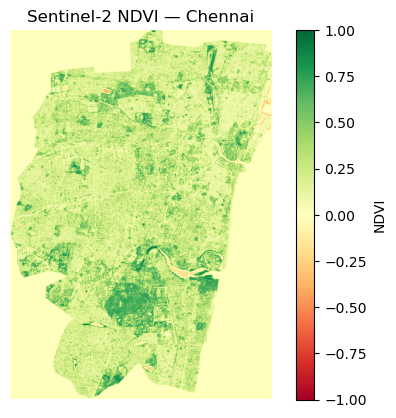

In [11]:
plt.imshow(
    ndvi,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="NDVI")
plt.title("Sentinel-2 NDVI — Chennai")
plt.axis("off")
plt.show()

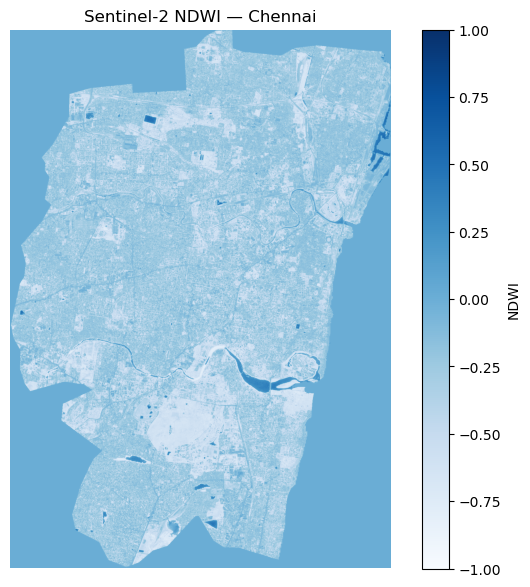

In [12]:
#NDWI
green = b3.read(1).astype("float32")
nir = b8.read(1).astype("float32")

green = np.ma.masked_equal(green, -99999)
nir = np.ma.masked_equal(nir, -99999)

ndwi = (green - nir) / (green + nir)

plt.figure(figsize=(8, 7))

plt.imshow(
    ndwi,
    cmap="Blues",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDWI")

plt.title("Sentinel-2 NDWI — Chennai")

plt.axis("off")

plt.show()

In [13]:
from rasterio.warp import reproject
from rasterio.enums import Resampling

In [14]:
swir = b11.read(1).astype("float32")

In [15]:
swir = b11.read(1).astype("float32")
swir_resampled = np.empty(
    (b8.height, b8.width),
    dtype="float32"
)

In [16]:
reproject(
    source=swir,
    destination=swir_resampled,
    src_transform=b11.transform,
    src_crs=b11.crs,
    dst_transform=b8.transform,
    dst_crs=b8.crs,
    src_nodata=-99999,
    dst_nodata=-99999,
    resampling=Resampling.bilinear
)

(array([[65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        ...,
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.]],
       dtype=float32),
 Affine(10.0, 0.0, 409930.0,
        0.0, -10.0, 1452090.0))

In [17]:
print("B8 shape:", b8.read(1).shape)
print("Resampled B11 shape:", swir_resampled.shape)

B8 shape: (2019, 1426)
Resampled B11 shape: (2019, 1426)


In [18]:
swir_resampled = np.ma.masked_equal(
    swir_resampled,
    -99999
)

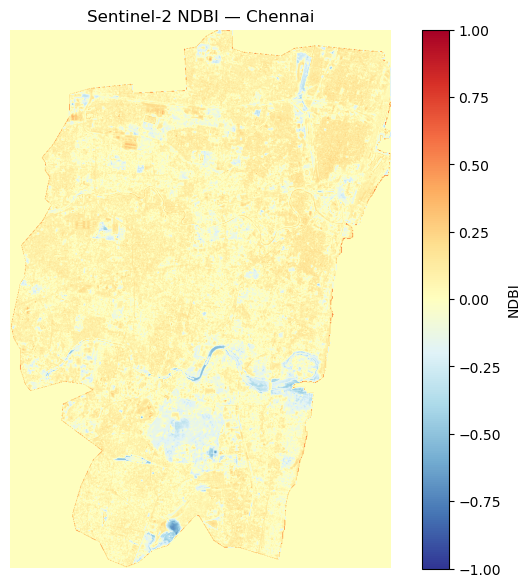

In [19]:
#NDBI
nir = b8.read(1).astype("float32")

nir = np.ma.masked_equal(
    nir,
    -99999
)

ndbi = (
    swir_resampled - nir
) / (
    swir_resampled + nir
)


plt.figure(figsize=(8, 7))

plt.imshow(
    ndbi,
    cmap="RdYlBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="NDBI")

plt.title("Sentinel-2 NDBI — Chennai")

plt.axis("off")

plt.show()

In [20]:
#EVI Enhanced vegitable Index

In [33]:
red = b4.read(1).astype("float32")
nir = b8.read(1).astype("float32")
blue = b3.read(1).astype("float32")

In [36]:
red = np.ma.masked_equal(red, -99999)
nir = np.ma.masked_equal(nir, -99999)
nir = np.ma.masked_equal(blue, -99999)


In [37]:
evi = 2.5 * (nir - red) / (nir + 6 * red - 7.5 * blue + 1)

In [38]:
plt.figure(figsize=(8, 7))

<Figure size 800x700 with 0 Axes>

<Figure size 800x700 with 0 Axes>

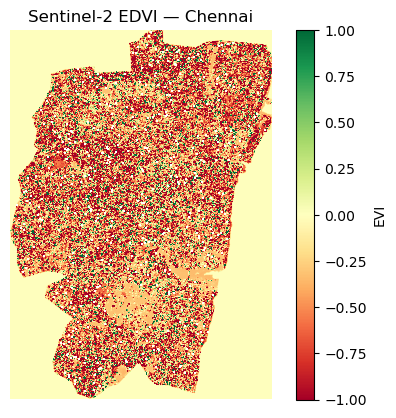

In [41]:
plt.imshow(
    evi,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)
plt.colorbar(label="EVI")
plt.title("Sentinel-2 EDVI — Chennai")
plt.axis("off")
plt.show()

In [ ]:
#NDMI Normalised Diff Moisture Index

In [42]:
nir = b8.read(1).astype('float32')
swir = b11.read(1).astype("float32")
swir_resampled = np.empty(
    (b8.height, b8.width),
    dtype="float32"
)

In [43]:
reproject(
    source=swir,
    destination=swir_resampled,
    src_transform=b11.transform,
    src_crs=b11.crs,
    dst_transform=b8.transform,
    dst_crs=b8.crs,
    src_nodata=-99999,
    dst_nodata=-99999,
    resampling=Resampling.bilinear
)

(array([[65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        ...,
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.],
        [65535., 65535., 65535., ..., 65535., 65535., 65535.]],
       dtype=float32),
 Affine(10.0, 0.0, 409930.0,
        0.0, -10.0, 1452090.0))

In [44]:
swir_resampled = np.ma.masked_equal(
    swir_resampled,
    -99999
)

In [45]:
#MDI

In [46]:
with np.errstate(divide='ignore', invalid='ignore'):
    ndmi = (nir - swir) / (nir + swir)

ValueError: operands could not be broadcast together with shapes (2019,1426) (1010,714) 

In [47]:
# 3. Compute NDMI while ignoring division-by-zero warnings
with np.errstate(divide='ignore', invalid='ignore'):
    ndmi = (nir - swir) / (nir + swir)
    
    # Optional: Replace any infinite or NaN values with 0
    ndmi = np.nan_to_num(ndmi, nan=0.0, posinf=0.0, neginf=0.0)

# 4. Plot the final index map
plt.figure(figsize=(10, 8))
plt.imshow(ndmi, cmap='RdYlBu')
plt.colorbar(label='NDMI Value')
plt.title('Normalized Difference Moisture Index (NDMI)')
plt.show()

ValueError: operands could not be broadcast together with shapes (2019,1426) (1010,714) 